# Biometric quality measures

Calculation of biometric quality measures from customer and imposter scores.

## Prepare data


In [34]:
clients_scores_A = []
with open("./data/scoresA_clientes") as f:
    lines = f.read().splitlines()
    for line in lines:
        clients_scores_A.append(float(line.split()[1]))
print("clients_scores_A:", clients_scores_A)

impostors_scores_A = []
with open("./data/scoresA_impostores") as f:
    lines = f.read().splitlines()
    for line in lines:
        impostors_scores_A.append(float(line.split()[1]))
print("impostors_scores_A:", impostors_scores_A)

clients_scores_B = []
with open("./data/scoresB_clientes") as f:
    lines = f.read().splitlines()
    for line in lines:
        clients_scores_B.append(float(line.split()[1]))
print("clients_scores_B:", clients_scores_B)

impostors_scores_B = []
with open("./data/scoresB_impostores") as f:
    lines = f.read().splitlines()
    for line in lines:
        impostors_scores_B.append(float(line.split()[1]))
print("impostors_scores_B:", impostors_scores_B)

clients_scores_A: [0.03466, 0.034054, 0.031746, 0.016118, 0.042146, 0.887626, 0.79962, 0.850384, 0.881088, 0.906191, 0.716958, 0.780591, 0.720313, 0.703284, 0.705813, 0.96732, 0.978799, 0.974646, 0.952886, 0.981689, 0.62933, 0.869258, 0.906675, 0.561194, 0.650267, 0.619048, 0.641085, 0.65277, 0.639316, 0.599084, 0.752132, 0.738195, 0.693817, 0.684302, 0.129555, 0.408033, 0.541274, 0.64557, 0.608595, 0.592849, 0.784059, 0.81328, 0.807955, 0.874859, 0.840515, 0.903263, 0.884192, 0.872414, 0.874352, 0.777842, 0.779509, 0.775498, 0.771171, 0.788638, 0.755464, 0.429958, 0.197368, 0.240167, 0.206792, 0.262843, 0.39627, 0.476896, 0.312684, 0.338355, 0.531727, 0.031877, 0.032634, 0.030642, 0.033819, 0.046552, 0.838814, 0.83961, 0.884961, 0.888179, 0.858662, 0.674499, 0.676169, 0.624434, 0.574732, 0.510863, 0.878882, 0.907049, 0.602706, 0.585652, 0.509125, 0.094719, 0.055991, 0.074286, 0.050058, 0.04504, 0.172598, 0.161894, 0.171611, 0.207481, 0.137391, 0.660777, 0.834218, 0.728273, 0.789504, 0

## ROC curve



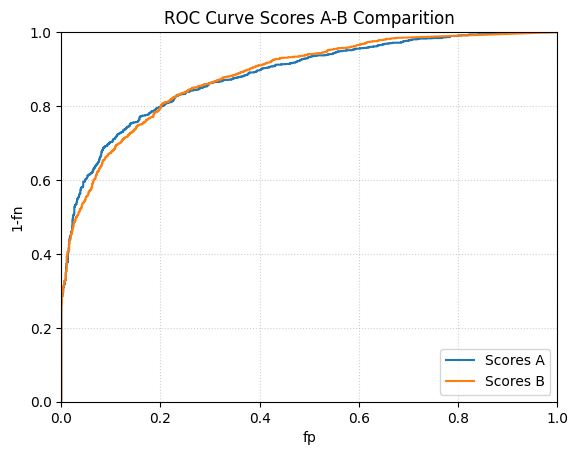

In [35]:
import matplotlib.pyplot as plt

# Scores A
thresholds = sorted(set([0] + clients_scores_A + impostors_scores_A + [1]))
x_scores_A = []
y_scores_A = []
for thresholds_step in thresholds:
    tp = sum(score >= thresholds_step for score in clients_scores_A)
    tn = sum(score < thresholds_step for score in impostors_scores_A)
    fp = sum(score >= thresholds_step for score in impostors_scores_A)
    fn = sum(score < thresholds_step for score in clients_scores_A)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
    x_scores_A.append(fpr)
    y_scores_A.append(1 - fnr)

# Scores B
thresholds = sorted(set([0] + clients_scores_B + impostors_scores_B + [1]))
x_scores_B = []
y_scores_B = []
for thresholds_step in thresholds:
    tp = sum(score >= thresholds_step for score in clients_scores_B)
    tn = sum(score < thresholds_step for score in impostors_scores_B)
    fp = sum(score >= thresholds_step for score in impostors_scores_B)
    fn = sum(score < thresholds_step for score in clients_scores_B)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
    x_scores_B.append(fpr)
    y_scores_B.append(1 - fnr)

# Plot ROC curve for Scores B
plt.plot(x_scores_A, y_scores_A, label='Scores A')
plt.plot(x_scores_B, y_scores_B, label='Scores B')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('fp')
plt.ylabel('1-fn')
plt.title('ROC Curve Scores A-B Comparition')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc= "lower right")
plt.show()

## FP(FN =X)yumbral